# Analyse de résultats de modèles de super-résolution

## Imports et préparation 

In [8]:
# Analyse experiments: VAE + SR-VAE
from pathlib import Path
import os
import random
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from tqdm import tqdm
import matplotlib.pyplot as plt
import json

from mri_image_normalizer import MRIImageNormalizer
from model_VAE import ConvVAE, vae_loss
from SR_VAE import ConvConditionalVAE, SRVAEConfig

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

ROOT = Path.cwd()  # expected: .../Dataset_cancer/ImageGeneration
HEALTHY_DIR = ROOT.parent / "Brain Tumor MRI images" / "Healthy"
print("Healthy dir:", HEALTHY_DIR)


Device: cpu
Healthy dir: /Users/julielevita/Desktop/kaggle_projects/Dataset_cancer/Brain Tumor MRI images/Healthy


## Super-résolution avec Conditional VAE

### Calcul du PSNR

#### Fonction de base

In [9]:

from typing import Optional

def psnr_torch(pred: torch.Tensor, target: torch.Tensor, max_val: float = 1.0) -> float:
    mse = F.mse_loss(pred, target).item()
    if mse == 0:
        return float("inf")
    return 20.0 * np.log10(max_val) - 10.0 * np.log10(mse)


def load_sr_vae_model(
    checkpoint_path: Path,
    high_size: int = 64,
    latent_dim: int = 64,
    cond_emb_dim: int = 128,
    base_channels: int = 64,
    device: torch.device = DEVICE,
):
    model = ConvConditionalVAE(
        img_channels=1,
        high_size=high_size,
        latent_dim=latent_dim,
        cond_emb_dim=cond_emb_dim,
        base_channels=base_channels,
    ).to(device)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()
    return model


def sr_from_low_and_show(
    model: ConvConditionalVAE,
    low_image_path: Path,
    high_image_path: Optional[Path] = None,
    low_size: int = 32,
    high_size: int = 64,
):
    low_norm = MRIImageNormalizer(target_size=(low_size, low_size), normalize_pixels=True)
    high_norm = MRIImageNormalizer(target_size=(high_size, high_size), normalize_pixels=True)

    low_arr = low_norm.process_single_image(str(low_image_path))
    if low_arr is None:
        raise RuntimeError(f"Cannot load low image: {low_image_path}")

    low_t = torch.from_numpy(low_arr).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        pseudo_high_t = model.sample_from_low(low_t)

    pseudo_high = pseudo_high_t.squeeze(0).cpu()

    # Same geometry as high for PSNR: nearest upsample of low (matches the visualization panel)
    low_up = F.interpolate(low_t.cpu(), size=(high_size, high_size), mode="nearest").squeeze(0)

    high_t = None
    psnr_value = None
    psnr_low_vs_high = None
    if high_image_path is not None:
        high_arr = high_norm.process_single_image(str(high_image_path))
        if high_arr is None:
            raise RuntimeError(f"Cannot load high image: {high_image_path}")
        high_t = torch.from_numpy(high_arr).permute(2, 0, 1).float()
        psnr_low_vs_high = psnr_torch(low_up, high_t)
        psnr_value = psnr_torch(pseudo_high, high_t)
        print(f"PSNR (low upsampled vs high): {psnr_low_vs_high:.2f} dB")
        print(f"PSNR (pseudo_high vs high): {psnr_value:.2f} dB")
        print(f"Δ PSNR (pseudo − low): {psnr_value - psnr_low_vs_high:+.2f} dB")

    # Display: low (upsampled for view), pseudo_high, high

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(low_up.squeeze(0).numpy(), cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Low (upsampled view)")
    axes[0].axis("off")

    axes[1].imshow(pseudo_high.squeeze(0).numpy(), cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Pseudo High (SR-VAE)")
    axes[1].axis("off")

    if high_t is not None:
        axes[2].imshow(high_t.squeeze(0).numpy(), cmap="gray", vmin=0, vmax=1)
        axes[2].set_title("True High")
    else:
        axes[2].imshow(np.zeros((high_size, high_size)), cmap="gray", vmin=0, vmax=1)
        axes[2].set_title("True High (not provided)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    return pseudo_high, psnr_value, psnr_low_vs_high


#### Utilisation du Manifest pour inspecter des exemples particuliers

Pair index: 102
Low : /Users/julielevita/Desktop/kaggle_projects/Dataset_cancer/ImageGeneration/Healthy_SR_pairs/scale_2/low/mri_healthy (109)_000102.jpg
High: /Users/julielevita/Desktop/kaggle_projects/Dataset_cancer/ImageGeneration/Healthy_SR_pairs/scale_2/high/mri_healthy (109)_000102.png
PSNR (low upsampled vs high): 21.49 dB
PSNR (pseudo_high vs high): 31.03 dB
Δ PSNR (pseudo − low): +9.55 dB


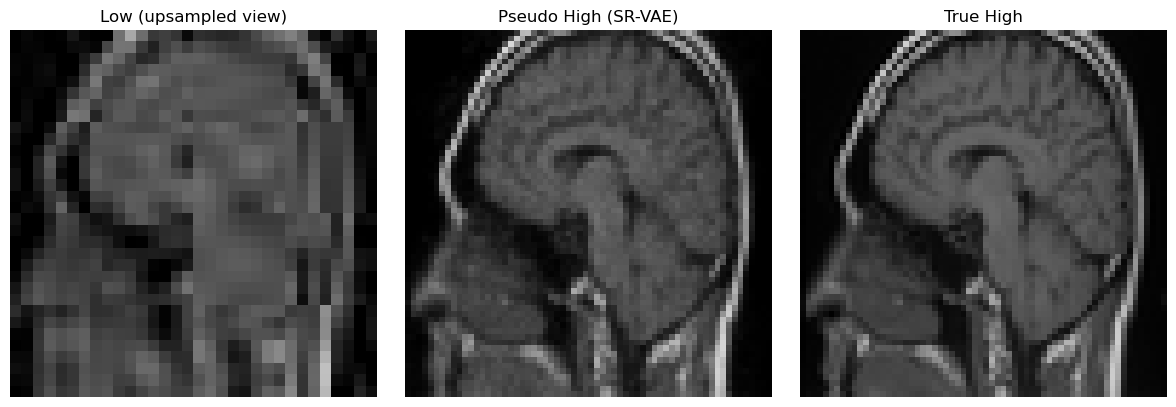

In [10]:

def _resolve_from_manifest(manifest_path: Path, maybe_path: str) -> Path:
    p = Path(maybe_path)
    if p.is_absolute():
        return p

    base = manifest_path.parent
    candidates = [
        (Path.cwd() / p).resolve(),
        (base / p).resolve(),
        (base.parent / p).resolve(),
    ]
    for c in candidates:
        if c.exists():
            return c

    return (base / p).resolve()


def sr_from_manifest_index(
    model: ConvConditionalVAE,
    manifest_path: Path,
    pair_index: int,
    low_size: int = 32,
    high_size: int = 64,
):
    if not manifest_path.exists():
        raise FileNotFoundError(f"Manifest not found: {manifest_path}")

    with open(manifest_path, "r", encoding="utf-8") as f:
        rows = [json.loads(line) for line in f if line.strip()]

    if pair_index < 0 or pair_index >= len(rows):
        raise IndexError(f"pair_index={pair_index} out of range [0, {len(rows)-1}]")

    rec = rows[pair_index]
    low_path = _resolve_from_manifest(manifest_path, rec["low_path"])
    high_path = _resolve_from_manifest(manifest_path, rec["high_path"])

    print(f"Pair index: {pair_index}")
    print(f"Low : {low_path}")
    print(f"High: {high_path}")

    return sr_from_low_and_show(
        model=model,
        low_image_path=low_path,
        high_image_path=high_path,
        low_size=low_size,
        high_size=high_size,
    )


# Modèle entraîné jusqu'à l'époque 50
sr_ckpt = ROOT / "ImageGeneration" / "sr_vae_outputs" / "sr_vae_epoch_050.pth"
manifest = ROOT / "Healthy_SR_pairs" / "scale_2" / "manifest.jsonl"

if sr_ckpt.exists() and manifest.exists():
    sr_model = load_sr_vae_model(sr_ckpt, high_size=64, latent_dim=64, cond_emb_dim=128, base_channels=64)

    # Choix de l'index de la paire à inspecter
    pair_index = 102

    _pseudo_high, _psnr_pseudo, _psnr_low = sr_from_manifest_index(
        model=sr_model,
        manifest_path=manifest,
        pair_index=pair_index,
        low_size=32,
        high_size=64,
    )
else:
    print("Checkpoint or manifest not found. Adjust paths in this cell.")


### Incertitude sur une paire (multi-échantillons SR-VAE)

Pour une même image **low**, le SR-VAE échantillonne $z \sim \mathcal{N}(0,I)$ puis décode : plusieurs appels donnent des **pseudo_high** différents. On calcule la **variance pixel à pixel** sur ces tirages pour repérer les zones où le modèle est le plus **instable** (risque d’évaluation / ambiguïté).

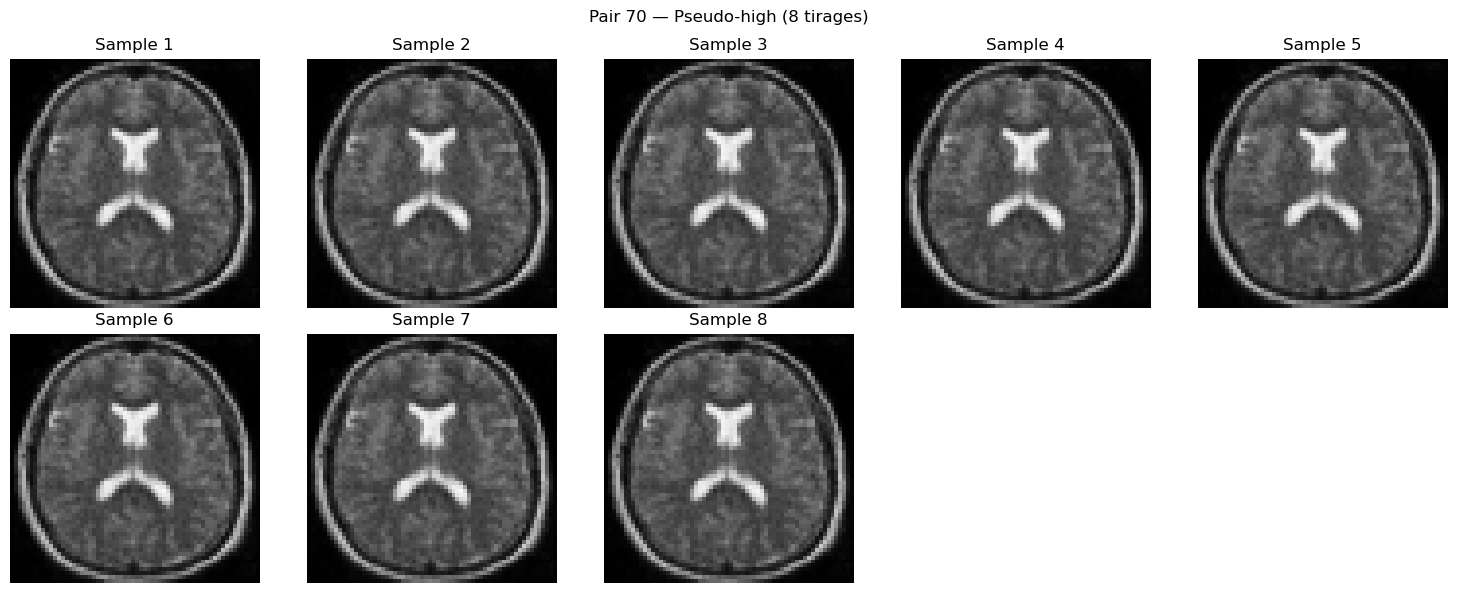

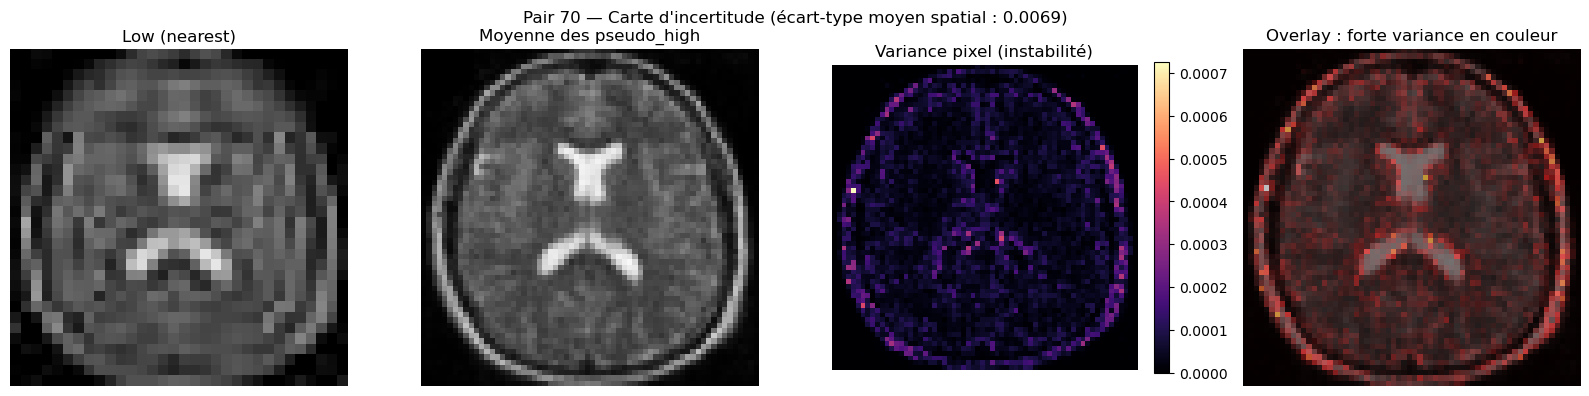

Variance moyenne (sur pixels): 0.000048
Écart-type moyen: 0.006913
Variance max: 0.000726


In [11]:
def multi_sample_uncertainty_from_manifest(
    model: ConvConditionalVAE,
    manifest_path: Path,
    pair_index: int,
    n_samples: int = 8,
    low_size: int = 32,
    high_size: int = 64,
    seed_offset: int = 0,
):
    """Plusieurs `sample_from_low` (z i.i.d. N(0,I)) pour une paire du manifest."""
    if not manifest_path.exists():
        raise FileNotFoundError(f"Manifest not found: {manifest_path}")

    with open(manifest_path, "r", encoding="utf-8") as f:
        rows = [json.loads(line) for line in f if line.strip()]

    if pair_index < 0 or pair_index >= len(rows):
        raise IndexError(f"pair_index={pair_index} out of range [0, {len(rows)-1}]")

    rec = rows[pair_index]
    low_path = _resolve_from_manifest(manifest_path, rec["low_path"])

    low_norm = MRIImageNormalizer(target_size=(low_size, low_size), normalize_pixels=True)
    low_arr = low_norm.process_single_image(str(low_path))
    if low_arr is None:
        raise RuntimeError(f"Cannot load low image: {low_path}")

    low_t = torch.from_numpy(low_arr).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
    low_up = F.interpolate(low_t.cpu(), size=(high_size, high_size), mode="nearest").squeeze(0)

    samples = []
    model.eval()
    with torch.no_grad():
        for i in range(n_samples):
            torch.manual_seed(SEED + seed_offset + i)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(SEED + seed_offset + i)
            out = model.sample_from_low(low_t).squeeze(0).cpu()
            samples.append(out)

    stack = torch.stack(samples, dim=0)
    mean_pseudo = stack.mean(dim=0)
    var_pseudo = stack.var(dim=0, unbiased=True)

    return {
        "low_path": low_path,
        "low_t": low_t.cpu(),
        "low_up": low_up,
        "samples": stack,
        "mean_pseudo": mean_pseudo,
        "var_pseudo": var_pseudo,
        "n_samples": n_samples,
    }


def show_sampling_uncertainty(result, pair_index=None, overlay_alpha=0.55):
    """Grille des tirages, moyenne, carte de variance, overlay sur la moyenne."""
    low_up = result["low_up"]
    stack = result["samples"]
    mean_pseudo = result["mean_pseudo"]
    var_map = result["var_pseudo"].squeeze(0).numpy()
    mean_np = mean_pseudo.squeeze(0).numpy()
    low_up_np = low_up.squeeze(0).numpy()
    n = stack.size(0)
    v = var_map.copy()
    v_min, v_max = float(v.min()), float(v.max())
    v_norm = np.zeros_like(v) if v_max <= v_min else (v - v_min) / (v_max - v_min)

    title_prefix = f"Pair {pair_index} — " if pair_index is not None else ""

    ncols = min(5, n)
    nrows = int(np.ceil(n / ncols))
    fig1, axes1 = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
    axes1 = np.atleast_1d(axes1).ravel()
    for i in range(nrows * ncols):
        ax = axes1[i]
        if i < n:
            ax.imshow(stack[i].squeeze(0).numpy(), cmap="gray", vmin=0, vmax=1)
            ax.set_title(f"Sample {i + 1}")
        ax.axis("off")
    fig1.suptitle(f"{title_prefix}Pseudo-high ({n} tirages)", fontsize=12)
    plt.tight_layout()
    plt.show()

    fig2, axes2 = plt.subplots(1, 4, figsize=(16, 4))
    axes2[0].imshow(low_up_np, cmap="gray", vmin=0, vmax=1)
    axes2[0].set_title("Low (nearest)")
    axes2[0].axis("off")

    axes2[1].imshow(mean_np, cmap="gray", vmin=0, vmax=1)
    axes2[1].set_title("Moyenne des pseudo_high")
    axes2[1].axis("off")

    im_v = axes2[2].imshow(v, cmap="magma")
    axes2[2].set_title("Variance pixel (instabilité)")
    axes2[2].axis("off")
    plt.colorbar(im_v, ax=axes2[2], fraction=0.046)

    axes2[3].imshow(mean_np, cmap="gray", vmin=0, vmax=1)
    axes2[3].imshow(v_norm, cmap="hot", alpha=overlay_alpha, vmin=0, vmax=1)
    axes2[3].set_title("Overlay : forte variance en couleur")
    axes2[3].axis("off")

    fig2.suptitle(
        f"{title_prefix}Carte d'incertitude (écart-type moyen spatial : {np.sqrt(v.mean()):.4f})",
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()

    print(f"Variance moyenne (sur pixels): {v.mean():.6f}")
    print(f"Écart-type moyen: {np.sqrt(v.mean()):.6f}")
    print(f"Variance max: {v_max:.6f}")


# Exemple : mêmes chemins que la cellule manifest (sr_model, manifest)
unc_pair_index = 70
n_stochastic_samples = 8

try:
    _unc_manifest = manifest
    _unc_model = sr_model
except NameError:
    print("Exécute d'abord la cellule manifest (sr_model, manifest) ou définis-les ici.")
else:
    if not _unc_manifest.exists():
        print(f"Manifest introuvable: {_unc_manifest}")
    else:
        unc = multi_sample_uncertainty_from_manifest(
            _unc_model,
            _unc_manifest,
            pair_index=unc_pair_index,
            n_samples=n_stochastic_samples,
            low_size=32,
            high_size=64,
        )
        show_sampling_uncertainty(unc, pair_index=unc_pair_index)

### Données **Tumor** (hors distribution)

Les paires low/high sont générées avec le même pipeline que pour Healthy : script `downsample_images.py` (64×64 PNG + 32×32 JPEG). Manifest : `Tumor_SR_pairs/scale_2/manifest.jsonl`.

**Régénérer le manifest** (depuis le dossier `ImageGeneration`, avec un environnement où `Pillow` est installé) :

```bash
python downsample_images.py --input_dir "../Brain Tumor MRI images/Tumor" --output_root "Tumor_SR_pairs/scale_2" --overwrite
```

Le modèle SR-VAE ci-dessous est celui entraîné sur **Healthy** : l’évaluation sur Tumor mesure le **transfert / dérive de domaine**.

--- Inspection visuelle (Tumor) ---
Pair index: 18
Low : /Users/julielevita/Desktop/kaggle_projects/Dataset_cancer/ImageGeneration/Tumor_SR_pairs/scale_2/low/glioma (115)_000018.jpg
High: /Users/julielevita/Desktop/kaggle_projects/Dataset_cancer/ImageGeneration/Tumor_SR_pairs/scale_2/high/glioma (115)_000018.png
PSNR (low upsampled vs high): 21.17 dB
PSNR (pseudo_high vs high): 20.17 dB
Δ PSNR (pseudo − low): -0.99 dB


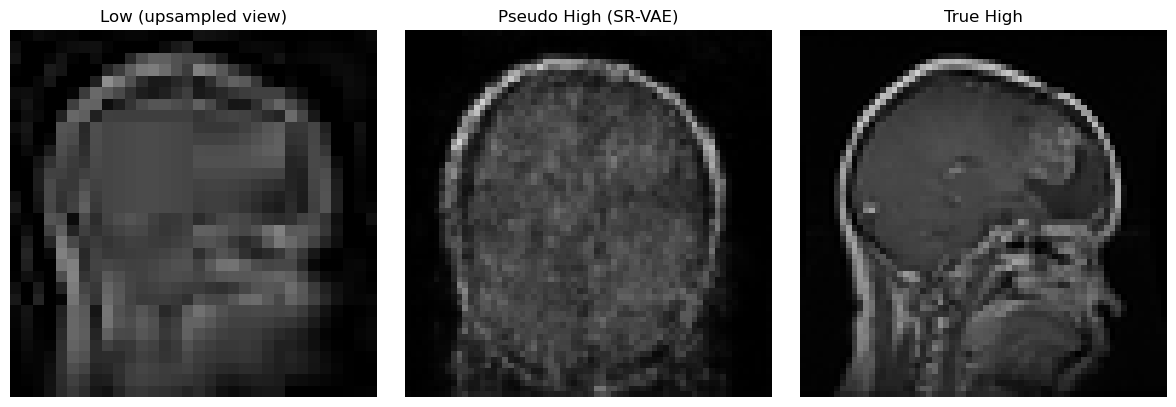


--- Moyennes PSNR sur un sous-ensemble ---


PSNR Tumor: 100%|██████████| 700/700 [00:05<00:00, 134.52it/s]

{'n_requested': 700, 'n_low': 700, 'n_pseudo': 700, 'mean_psnr_low_vs_high': 23.130401896986502, 'mean_psnr_pseudo_vs_high': 21.84458516435506}
Δ PSNR moyen (pseudo − low): -1.29 dB


In [12]:
manifest_tumor = ROOT / "Tumor_SR_pairs" / "scale_2" / "manifest.jsonl"
_sr_ckpt_tumor = ROOT / "ImageGeneration" / "sr_vae_outputs" / "sr_vae_epoch_050.pth"


@torch.no_grad()
def psnrs_for_manifest_pair(model, manifest_path: Path, pair_index: int, low_size: int = 32, high_size: int = 64):
    """PSNR low upsamplée vs high et pseudo_high vs high (un tirage z, graine fixe par appel)."""
    with open(manifest_path, "r", encoding="utf-8") as f:
        rows = [json.loads(line) for line in f if line.strip()]
    rec = rows[pair_index]
    low_path = _resolve_from_manifest(manifest_path, rec["low_path"])
    high_path = _resolve_from_manifest(manifest_path, rec["high_path"])
    low_norm = MRIImageNormalizer(target_size=(low_size, low_size), normalize_pixels=True)
    high_norm = MRIImageNormalizer(target_size=(high_size, high_size), normalize_pixels=True)
    low_arr = low_norm.process_single_image(str(low_path))
    high_arr = high_norm.process_single_image(str(high_path))
    if low_arr is None or high_arr is None:
        return None
    low_t = torch.from_numpy(low_arr).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
    high_t = torch.from_numpy(high_arr).permute(2, 0, 1).float()
    low_up = F.interpolate(low_t.cpu(), size=(high_size, high_size), mode="nearest").squeeze(0)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    pseudo_high = model.sample_from_low(low_t).squeeze(0).cpu()
    return {
        "psnr_low_vs_high": psnr_torch(low_up, high_t),
        "psnr_pseudo_vs_high": psnr_torch(pseudo_high, high_t),
    }


def mean_psnr_on_manifest_subset(
    model,
    manifest_path: Path,
    max_pairs: int = 300,
    low_size: int = 32,
    high_size: int = 64,
):
    with open(manifest_path, "r", encoding="utf-8") as f:
        rows = [json.loads(line) for line in f if line.strip()]
    n = min(max_pairs, len(rows))
    lows, pseudos = [], []
    for i in tqdm(range(n), desc="PSNR Tumor"):
        out = psnrs_for_manifest_pair(model, manifest_path, i, low_size, high_size)
        if out is None:
            continue
        pl, pp = out["psnr_low_vs_high"], out["psnr_pseudo_vs_high"]
        if np.isfinite(pl):
            lows.append(pl)
        if np.isfinite(pp):
            pseudos.append(pp)
    return {
        "n_requested": n,
        "n_low": len(lows),
        "n_pseudo": len(pseudos),
        "mean_psnr_low_vs_high": float(np.mean(lows)) if lows else float("nan"),
        "mean_psnr_pseudo_vs_high": float(np.mean(pseudos)) if pseudos else float("nan"),
    }


# --- Qualitatif : une paire Tumor
tumor_pair_index = 18

if not manifest_tumor.exists():
    print(f"Manifest Tumor absent : {manifest_tumor}")
    print("Lance downsample_images.py (voir la cellule markdown au-dessus).")
elif not _sr_ckpt_tumor.exists():
    print(f"Checkpoint absent : {_sr_ckpt_tumor}")
else:
    if "sr_model" not in dir():
        sr_model = load_sr_vae_model(
            _sr_ckpt_tumor, high_size=64, latent_dim=64, cond_emb_dim=128, base_channels=64
        )
    print("--- Inspection visuelle (Tumor) ---")
    sr_from_manifest_index(
        model=sr_model,
        manifest_path=manifest_tumor,
        pair_index=tumor_pair_index,
        low_size=32,
        high_size=64,
    )

    print("\n--- Moyennes PSNR sur un sous-ensemble ---")
    stats = mean_psnr_on_manifest_subset(sr_model, manifest_tumor, max_pairs=700)
    print(stats)
    if stats["n_pseudo"]:
        print(
            f"Δ PSNR moyen (pseudo − low): "
            f"{stats['mean_psnr_pseudo_vs_high'] - stats['mean_psnr_low_vs_high']:+.2f} dB"
        )

## Super-résolution **par diffusion** (SR-Diffusion)

On charge un checkpoint `sr_diffusion_epoch_XXX.pth` et on génère `pseudo_high` à partir de la **low** via DDIM (conditionné). Affichage identique : **low upsamplée | pseudo_high | high**, + **PSNR low→high** et **PSNR pseudo→high**.

Pair index: 80
Low : /Users/julielevita/Desktop/kaggle_projects/Dataset_cancer/ImageGeneration/Healthy_SR_pairs/scale_2/low/mri_healthy (107)_000080.jpg
High: /Users/julielevita/Desktop/kaggle_projects/Dataset_cancer/ImageGeneration/Healthy_SR_pairs/scale_2/high/mri_healthy (107)_000080.png
PSNR (low upsampled vs high): 16.13 dB
PSNR (pseudo_high vs high): 17.70 dB
Δ PSNR (pseudo − low): +1.57 dB


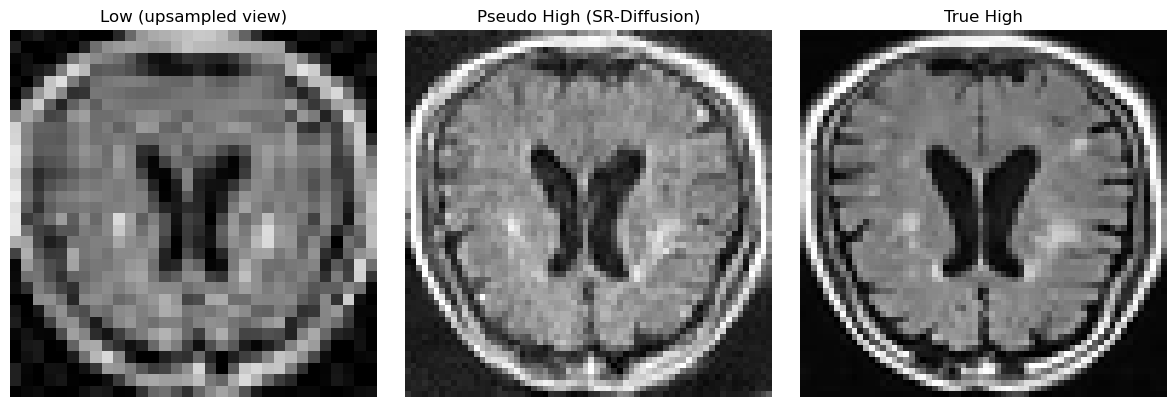

In [23]:
from typing import Optional

from model_diffusion import DDPMScheduler

# Import du modèle diffusion SR (fichier ImageGeneration/sr_diffusion.py)
# (sur macOS le FS peut être insensible à la casse, on garde sr_diffusion)
from SR_diffusion import ConditionalSRUNet, SRDiffusionConfig, sample_ddim_cond


def _to_01(x_neg1_1: torch.Tensor) -> torch.Tensor:
    x = (x_neg1_1 + 1.0) / 2.0
    return torch.clamp(x, 0.0, 1.0)


def load_sr_diffusion(
    checkpoint_path: Path,
    device: torch.device = DEVICE,
    high_size: int = 64,
    img_channels: int = 1,
    base_channels: int = 64,
    timesteps: int = 1000,
    beta_start: float = 1e-4,
    beta_end: float = 2e-2,
):
    model = ConditionalSRUNet(
        img_channels=img_channels,
        cond_channels=1,
        high_size=high_size,
        base_channels=base_channels,
        time_dim=256,
    ).to(device)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

    scheduler = DDPMScheduler(
        timesteps=timesteps,
        beta_start=beta_start,
        beta_end=beta_end,
        device=device,
    )
    return model, scheduler


def sr_diffusion_from_low_and_show(
    model: ConditionalSRUNet,
    scheduler: DDPMScheduler,
    low_image_path: Path,
    high_image_path: Optional[Path] = None,
    low_size: int = 32,
    high_size: int = 64,
    ddim_steps: int = 50,
    ddim_eta: float = 0.0,
):
    low_norm = MRIImageNormalizer(target_size=(low_size, low_size), normalize_pixels=True)
    high_norm = MRIImageNormalizer(target_size=(high_size, high_size), normalize_pixels=True)

    low_arr = low_norm.process_single_image(str(low_image_path))
    if low_arr is None:
        raise RuntimeError(f"Cannot load low image: {low_image_path}")

    low_t = torch.from_numpy(low_arr).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        pseudo_neg1_1 = sample_ddim_cond(
            scheduler,
            model,
            low_t,
            img_channels=1,
            high_size=high_size,
            steps=ddim_steps,
            eta=ddim_eta,
        )

    pseudo_high = _to_01(pseudo_neg1_1).squeeze(0).cpu()

    # même géométrie que high pour PSNR : low upsamplée (nearest, comme pour SR-VAE)
    low_up = F.interpolate(low_t.cpu(), size=(high_size, high_size), mode="nearest").squeeze(0)

    high_t = None
    psnr_pseudo_vs_high = None
    psnr_low_vs_high = None
    if high_image_path is not None:
        high_arr = high_norm.process_single_image(str(high_image_path))
        if high_arr is None:
            raise RuntimeError(f"Cannot load high image: {high_image_path}")
        high_t = torch.from_numpy(high_arr).permute(2, 0, 1).float()

        psnr_low_vs_high = psnr_torch(low_up, high_t)
        psnr_pseudo_vs_high = psnr_torch(pseudo_high, high_t)
        print(f"PSNR (low upsampled vs high): {psnr_low_vs_high:.2f} dB")
        print(f"PSNR (pseudo_high vs high): {psnr_pseudo_vs_high:.2f} dB")
        print(f"Δ PSNR (pseudo − low): {psnr_pseudo_vs_high - psnr_low_vs_high:+.2f} dB")

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(low_up.squeeze(0).numpy(), cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Low (upsampled view)")
    axes[0].axis("off")

    axes[1].imshow(pseudo_high.squeeze(0).numpy(), cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Pseudo High (SR-Diffusion)")
    axes[1].axis("off")

    if high_t is not None:
        axes[2].imshow(high_t.squeeze(0).numpy(), cmap="gray", vmin=0, vmax=1)
        axes[2].set_title("True High")
    else:
        axes[2].imshow(np.zeros((high_size, high_size)), cmap="gray", vmin=0, vmax=1)
        axes[2].set_title("True High (not provided)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    return pseudo_high, psnr_pseudo_vs_high, psnr_low_vs_high


def sr_diffusion_from_manifest_index(
    model: ConditionalSRUNet,
    scheduler: DDPMScheduler,
    manifest_path: Path,
    pair_index: int,
    low_size: int = 32,
    high_size: int = 64,
    ddim_steps: int = 50,
    ddim_eta: float = 0.0,
):
    if not manifest_path.exists():
        raise FileNotFoundError(f"Manifest not found: {manifest_path}")

    with open(manifest_path, "r", encoding="utf-8") as f:
        rows = [json.loads(line) for line in f if line.strip()]

    if pair_index < 0 or pair_index >= len(rows):
        raise IndexError(f"pair_index={pair_index} out of range [0, {len(rows)-1}]")

    rec = rows[pair_index]
    low_path = _resolve_from_manifest(manifest_path, rec["low_path"])
    high_path = _resolve_from_manifest(manifest_path, rec["high_path"])

    print(f"Pair index: {pair_index}")
    print(f"Low : {low_path}")
    print(f"High: {high_path}")

    return sr_diffusion_from_low_and_show(
        model=model,
        scheduler=scheduler,
        low_image_path=low_path,
        high_image_path=high_path,
        low_size=low_size,
        high_size=high_size,
        ddim_steps=ddim_steps,
        ddim_eta=ddim_eta,
    )


# --- Exemple (Healthy) ---
# On accepte 2 layouts possibles selon où le training a été lancé.
ckpt_candidates = [
    ROOT / "ImageGeneration" / "sr_diffusion_outputs" / "sr_diffusion_epoch_045.pth",
    ROOT / "ImageGeneration" / "ImageGeneration" / "sr_diffusion_outputs" / "sr_diffusion_epoch_050.pth",
    ROOT / "sr_diffusion_outputs" / "sr_diffusion_epoch_050.pth",
]

sr_diff_ckpt = next((p for p in ckpt_candidates if p.exists()), None)

if sr_diff_ckpt is None:
    print("Checkpoint SR-Diffusion introuvable. Cherché :")
    for p in ckpt_candidates:
        print(" -", p)
else:
    # mêmes tailles que la préparation des paires
    cfg = SRDiffusionConfig()
    # charge modèle + scheduler (betas/timesteps cohérents avec cfg)
    sr_diff_model, sr_diff_sched = load_sr_diffusion(
        sr_diff_ckpt,
        high_size=cfg.high_size,
        img_channels=cfg.img_channels,
        base_channels=cfg.base_channels,
        timesteps=cfg.timesteps,
        beta_start=cfg.beta_start,
        beta_end=cfg.beta_end,
    )

    # utilise le manifest déjà défini plus haut si dispo (Healthy), sinon retombe sur un chemin standard
    try:
        _m = manifest
    except NameError:
        _m = ROOT / "Healthy_SR_pairs" / "scale_2" / "manifest.jsonl"

    if not _m.exists():
        print(f"Manifest introuvable: {_m}")
    else:
        diff_pair_index = 80
        _pseudo_high_diff, _psnr_pseudo_diff, _psnr_low_diff = sr_diffusion_from_manifest_index(
            model=sr_diff_model,
            scheduler=sr_diff_sched,
            manifest_path=_m,
            pair_index=diff_pair_index,
            low_size=cfg.low_size,
            high_size=cfg.high_size,
            ddim_steps=cfg.ddim_steps,
            ddim_eta=cfg.ddim_eta,
        )

SR-Diffusion uncertainty: eta=0.5, steps=50, n=8


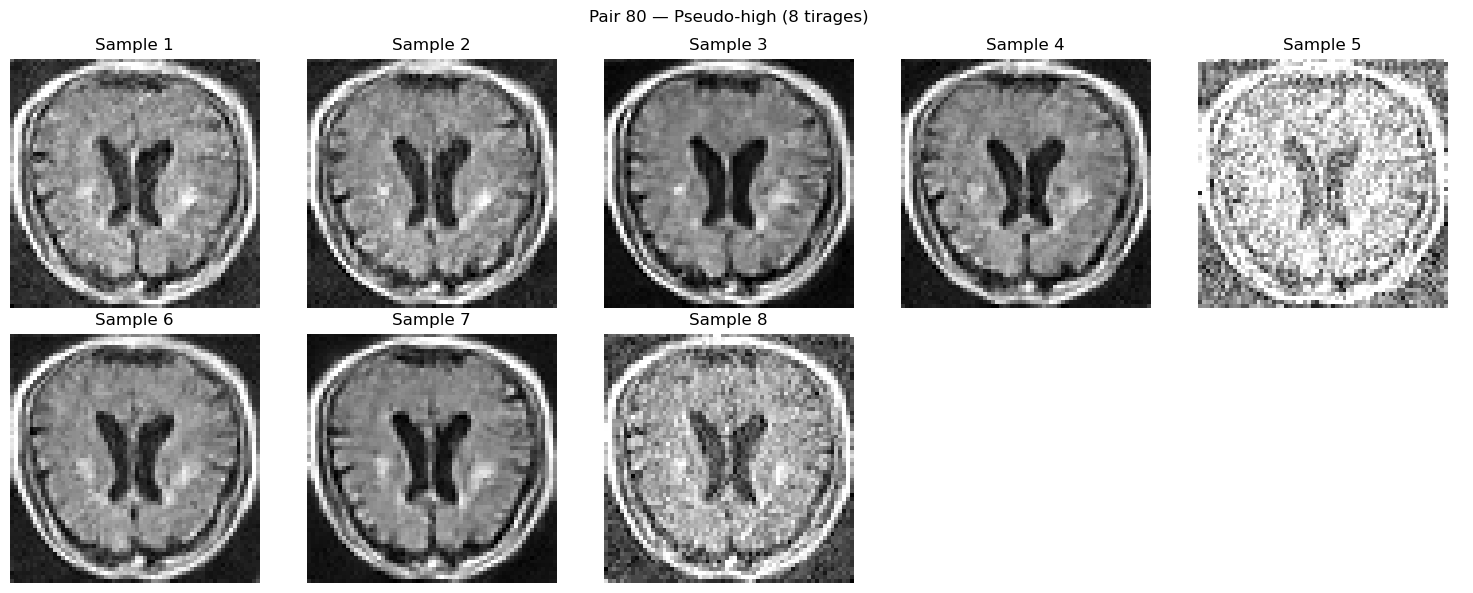

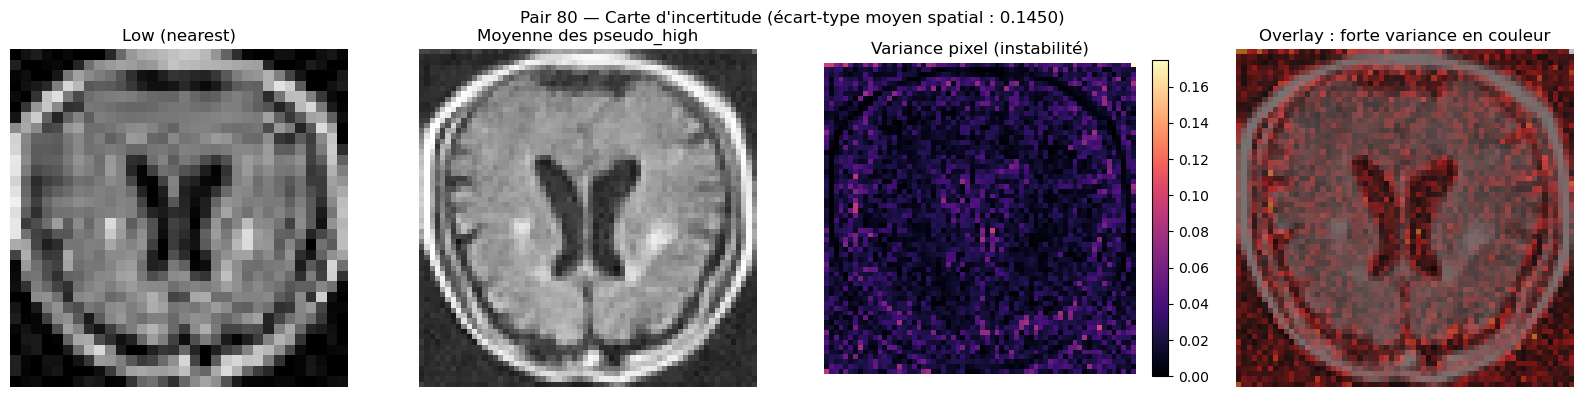

Variance moyenne (sur pixels): 0.021023
Écart-type moyen: 0.144995
Variance max: 0.174807


In [24]:
# --- Incertitude / variance (SR-Diffusion) ---
# On génère N pseudo_high pour une même low (DDIM stochastique si eta>0)

@torch.no_grad()
def multi_sample_uncertainty_diffusion_from_manifest(
    model: ConditionalSRUNet,
    scheduler: DDPMScheduler,
    manifest_path: Path,
    pair_index: int,
    n_samples: int = 8,
    low_size: int = 32,
    high_size: int = 64,
    ddim_steps: int = 50,
    ddim_eta: float = 0.5,
    seed_offset: int = 0,
):
    if not manifest_path.exists():
        raise FileNotFoundError(f"Manifest not found: {manifest_path}")

    with open(manifest_path, "r", encoding="utf-8") as f:
        rows = [json.loads(line) for line in f if line.strip()]

    if pair_index < 0 or pair_index >= len(rows):
        raise IndexError(f"pair_index={pair_index} out of range [0, {len(rows)-1}]")

    rec = rows[pair_index]
    low_path = _resolve_from_manifest(manifest_path, rec["low_path"])

    low_norm = MRIImageNormalizer(target_size=(low_size, low_size), normalize_pixels=True)
    low_arr = low_norm.process_single_image(str(low_path))
    if low_arr is None:
        raise RuntimeError(f"Cannot load low image: {low_path}")

    low_t = torch.from_numpy(low_arr).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
    low_up = F.interpolate(low_t.cpu(), size=(high_size, high_size), mode="nearest").squeeze(0)

    samples = []
    model.eval()
    for i in range(n_samples):
        torch.manual_seed(SEED + seed_offset + i)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED + seed_offset + i)

        pseudo_neg1_1 = sample_ddim_cond(
            scheduler,
            model,
            low_t,
            img_channels=1,
            high_size=high_size,
            steps=ddim_steps,
            eta=ddim_eta,
        )
        pseudo_01 = _to_01(pseudo_neg1_1).squeeze(0).cpu()
        samples.append(pseudo_01)

    stack = torch.stack(samples, dim=0)
    mean_pseudo = stack.mean(dim=0)
    var_pseudo = stack.var(dim=0, unbiased=True)

    return {
        "low_path": low_path,
        "low_t": low_t.cpu(),
        "low_up": low_up,
        "samples": stack,
        "mean_pseudo": mean_pseudo,
        "var_pseudo": var_pseudo,
        "n_samples": n_samples,
        "ddim_eta": ddim_eta,
        "ddim_steps": ddim_steps,
    }


# Exemple : réutilise sr_diff_model / sr_diff_sched / _m si disponibles
try:
    _unc_diff_model = sr_diff_model
    _unc_diff_sched = sr_diff_sched
except NameError:
    print("Exécute d'abord la cellule SR-Diffusion (chargement du modèle + scheduler).")
else:
    # manifest
    try:
        _unc_diff_manifest = _m
    except NameError:
        try:
            _unc_diff_manifest = manifest
        except NameError:
            _unc_diff_manifest = ROOT / "Healthy_SR_pairs" / "scale_2" / "manifest.jsonl"

    diff_unc_pair_index = 80
    diff_unc_n_samples = 8

    # eta > 0 => diversité (incertitude de sampling)
    diff_unc_ddim_eta = 0.5

    if not Path(_unc_diff_manifest).exists():
        print(f"Manifest introuvable: {_unc_diff_manifest}")
    else:
        unc_diff = multi_sample_uncertainty_diffusion_from_manifest(
            model=_unc_diff_model,
            scheduler=_unc_diff_sched,
            manifest_path=Path(_unc_diff_manifest),
            pair_index=diff_unc_pair_index,
            n_samples=diff_unc_n_samples,
            low_size=cfg.low_size if 'cfg' in dir() else 32,
            high_size=cfg.high_size if 'cfg' in dir() else 64,
            ddim_steps=cfg.ddim_steps if 'cfg' in dir() else 50,
            ddim_eta=diff_unc_ddim_eta,
        )
        print(
            f"SR-Diffusion uncertainty: eta={unc_diff['ddim_eta']}, steps={unc_diff['ddim_steps']}, n={unc_diff['n_samples']}"
        )
        show_sampling_uncertainty(unc_diff, pair_index=diff_unc_pair_index)
